<a href="https://colab.research.google.com/github/TrishKedi/weather-adaptive-object-detection-autonomous-driving/blob/main/DataPreprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Step 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Step 2: Set the path to your ZIP file in Drive
zip_path = '/content/drive/My Drive/ML_CASE_STUDY/dataset.zip'  # ← change this to match your zip file path

In [ ]:
# Step 3: Unzip the file into a working directory
import zipfile
import os

extract_dir = '/content'
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print("✅ Dataset extracted to:", extract_dir)

✅ Dataset extracted to: /content


In [ ]:
from transformers import DetrForObjectDetection

processor = DetrForObjectDetection.from_pretrained("facebook/detr-resnet-50")
id2label = processor.config.id2label
print(id2label)

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:2397: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:2397: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:2397: UserWarning: for bn1.bias: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pas

{0: 'N/A', 1: 'person', 10: 'traffic light', 11: 'fire hydrant', 12: 'street sign', 13: 'stop sign', 14: 'parking meter', 15: 'bench', 16: 'bird', 17: 'cat', 18: 'dog', 19: 'horse', 2: 'bicycle', 20: 'sheep', 21: 'cow', 22: 'elephant', 23: 'bear', 24: 'zebra', 25: 'giraffe', 26: 'hat', 27: 'backpack', 28: 'umbrella', 29: 'shoe', 3: 'car', 30: 'eye glasses', 31: 'handbag', 32: 'tie', 33: 'suitcase', 34: 'frisbee', 35: 'skis', 36: 'snowboard', 37: 'sports ball', 38: 'kite', 39: 'baseball bat', 4: 'motorcycle', 40: 'baseball glove', 41: 'skateboard', 42: 'surfboard', 43: 'tennis racket', 44: 'bottle', 45: 'plate', 46: 'wine glass', 47: 'cup', 48: 'fork', 49: 'knife', 5: 'airplane', 50: 'spoon', 51: 'bowl', 52: 'banana', 53: 'apple', 54: 'sandwich', 55: 'orange', 56: 'broccoli', 57: 'carrot', 58: 'hot dog', 59: 'pizza', 6: 'bus', 60: 'donut', 61: 'cake', 62: 'chair', 63: 'couch', 64: 'potted plant', 65: 'bed', 66: 'mirror', 67: 'dining table', 68: 'window', 69: 'desk', 7: 'train', 70: 'toi

In [ ]:
from transformers import DetrForObjectDetection
from pycocotools.coco import COCO

def build_label_remap(coco_ann_path):
    # Load your dataset's categories
    coco = COCO(coco_ann_path)
    your_cats = coco.loadCats(coco.getCatIds())
    your_name_to_id = {cat['name'].lower(): cat['id'] for cat in your_cats}

    # Load DETR’s COCO label names
    model = DetrForObjectDetection.from_pretrained("facebook/detr-resnet-50")
    id2label = model.config.id2label  # index → name
    detr_classes = [id2label[i].lower() for i in range(len(id2label))]

    # Build remap: DETR index → your dataset's category_id
    remap = {}
    for detr_id, name in enumerate(detr_classes):
        if name in your_name_to_id:
            remap[detr_id] = your_name_to_id[name]

    print(f"✅ Built remap for {len(remap)} matching classes:")
    print(remap)
    return remap


In [ ]:
from transformers import DetrForObjectDetection
from pycocotools.coco import COCO

def build_label_remap(coco_ann_path):
    # Normalization mapping: COCO class name → your dataset's category name
    name_normalization = {
        "person": "person",
        "bicycle": "bike",
        "car": "car",
        "motorcycle": "motor",
        "bus": "bus",
        "truck": "truck",
        "traffic light": "traffic light"
        # "traffic sign" and "rider" are not in COCO, so we skip them
    }

    # Load your dataset categories
    coco = COCO(coco_ann_path)
    your_cats = coco.loadCats(coco.getCatIds())
    your_name_to_id = {cat["name"].lower(): cat["id"] for cat in your_cats}
    # print(your_name_to_id)

    # Load DETR model to get id2label
    model = DetrForObjectDetection.from_pretrained("facebook/detr-resnet-50")
    id2label = model.config.id2label  # {int: str}
    # print(id2label)

    # Build remap: DETR class index → your dataset's category_id
    remap = {}
    for detr_id, coco_label in id2label.items():
        normalized_name = name_normalization.get(coco_label.lower())

        if normalized_name and normalized_name in your_name_to_id:
            remap[detr_id] = your_name_to_id[normalized_name]

    print(f"✅ Built remap for {len(remap)} matching classes:")
    print(remap)
    return remap


In [ ]:
import os
import json
import torch
from tqdm import tqdm
from PIL import Image
from transformers import DetrForObjectDetection, DetrImageProcessor
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval


VAL_ROOT = "/content/dataset/dataset/val"
img_dir = os.path.join(VAL_ROOT, "clear", "images")
ann_file = os.path.join(VAL_ROOT, "clear", "coco_annotations.json")
coco_gt = COCO(ann_file)
remap = build_label_remap(ann_file)

loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
{'car': 1, 'truck': 2, 'person': 3, 'bike': 4, 'traffic sign': 5, 'traffic light': 6, 'bus': 7, 'motor': 8, 'rider': 9}


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:2397: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:2397: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:2397: UserWarning: for bn1.bias: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pas

{0: 'N/A', 1: 'person', 10: 'traffic light', 11: 'fire hydrant', 12: 'street sign', 13: 'stop sign', 14: 'parking meter', 15: 'bench', 16: 'bird', 17: 'cat', 18: 'dog', 19: 'horse', 2: 'bicycle', 20: 'sheep', 21: 'cow', 22: 'elephant', 23: 'bear', 24: 'zebra', 25: 'giraffe', 26: 'hat', 27: 'backpack', 28: 'umbrella', 29: 'shoe', 3: 'car', 30: 'eye glasses', 31: 'handbag', 32: 'tie', 33: 'suitcase', 34: 'frisbee', 35: 'skis', 36: 'snowboard', 37: 'sports ball', 38: 'kite', 39: 'baseball bat', 4: 'motorcycle', 40: 'baseball glove', 41: 'skateboard', 42: 'surfboard', 43: 'tennis racket', 44: 'bottle', 45: 'plate', 46: 'wine glass', 47: 'cup', 48: 'fork', 49: 'knife', 5: 'airplane', 50: 'spoon', 51: 'bowl', 52: 'banana', 53: 'apple', 54: 'sandwich', 55: 'orange', 56: 'broccoli', 57: 'carrot', 58: 'hot dog', 59: 'pizza', 6: 'bus', 60: 'donut', 61: 'cake', 62: 'chair', 63: 'couch', 64: 'potted plant', 65: 'bed', 66: 'mirror', 67: 'dining table', 68: 'window', 69: 'desk', 7: 'train', 70: 'toi

Some weights of the model checkpoint at facebook/detr-resnet-50 were not used when initializing DetrForObjectDetection: ['model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing DetrForObjectDetection from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DetrForObjectDetection from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
loading annotations into memory...
Done (t=0.02s)
creating index...
index created!
{'traffic light': 1, 'traffic sign': 2, 'car': 3, 'bus': 4, 'truck': 5, 'person': 6, 'bike': 7, 'motor': 8, 'rider': 9}


Some weights of the model checkpoint at facebook/detr-resnet-50 were not used when initializing DetrForObjectDetection: ['model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing DetrForObjectDetection from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DetrForObjectDetection from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


{0: 'N/A', 1: 'person', 10: 'traffic light', 11: 'fire hydrant', 12: 'street sign', 13: 'stop sign', 14: 'parking meter', 15: 'bench', 16: 'bird', 17: 'cat', 18: 'dog', 19: 'horse', 2: 'bicycle', 20: 'sheep', 21: 'cow', 22: 'elephant', 23: 'bear', 24: 'zebra', 25: 'giraffe', 26: 'hat', 27: 'backpack', 28: 'umbrella', 29: 'shoe', 3: 'car', 30: 'eye glasses', 31: 'handbag', 32: 'tie', 33: 'suitcase', 34: 'frisbee', 35: 'skis', 36: 'snowboard', 37: 'sports ball', 38: 'kite', 39: 'baseball bat', 4: 'motorcycle', 40: 'baseball glove', 41: 'skateboard', 42: 'surfboard', 43: 'tennis racket', 44: 'bottle', 45: 'plate', 46: 'wine glass', 47: 'cup', 48: 'fork', 49: 'knife', 5: 'airplane', 50: 'spoon', 51: 'bowl', 52: 'banana', 53: 'apple', 54: 'sandwich', 55: 'orange', 56: 'broccoli', 57: 'carrot', 58: 'hot dog', 59: 'pizza', 6: 'bus', 60: 'donut', 61: 'cake', 62: 'chair', 63: 'couch', 64: 'potted plant', 65: 'bed', 66: 'mirror', 67: 'dining table', 68: 'window', 69: 'desk', 7: 'train', 70: 'toi

FOGGY Inference:   0%|          | 0/529 [00:00<?, ?it/s]

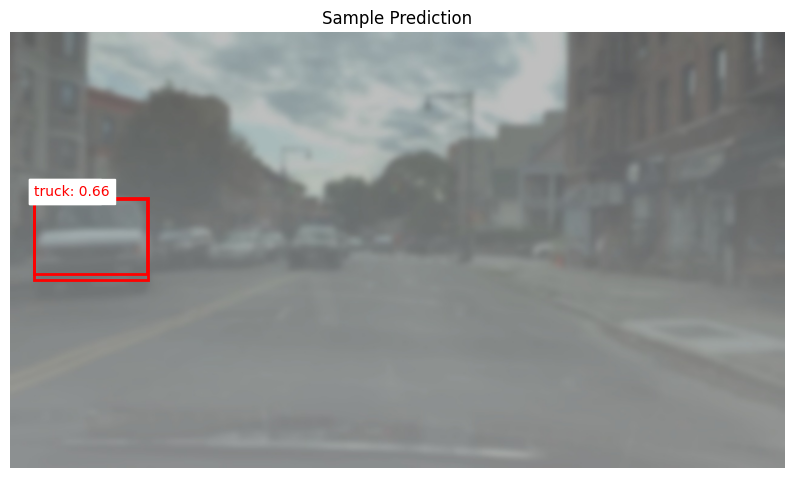

FOGGY Inference:   0%|          | 2/529 [00:00<02:15,  3.88it/s]

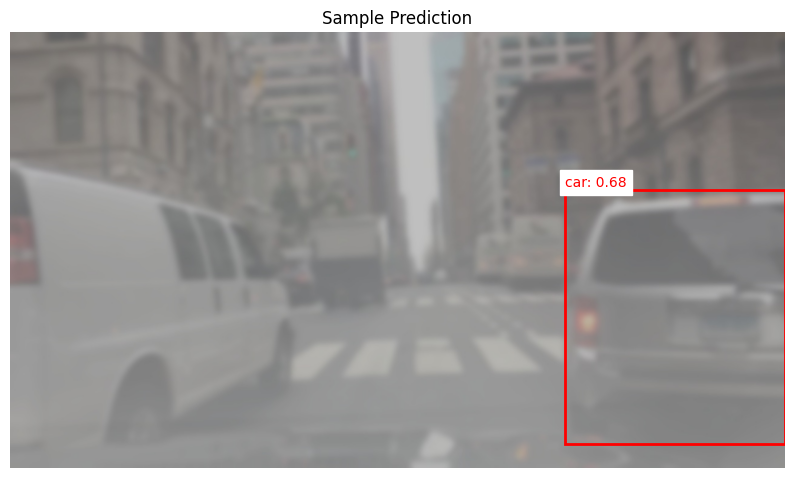

FOGGY Inference:   1%|          | 3/529 [00:00<02:37,  3.35it/s]

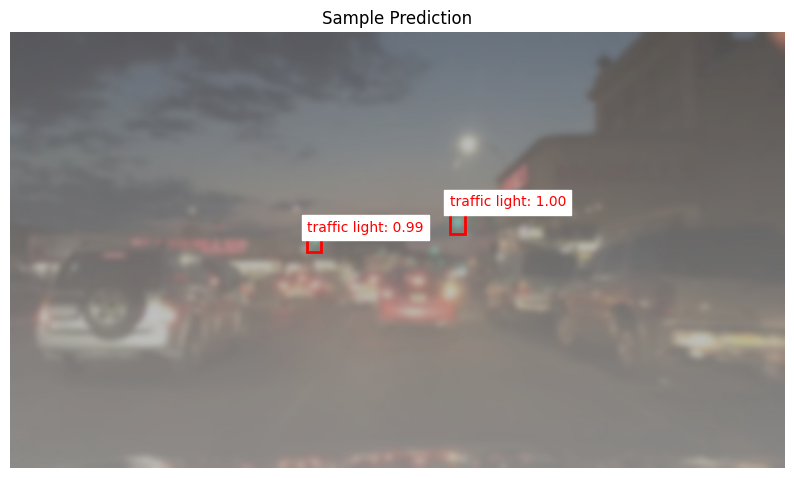

FOGGY Inference:   1%|          | 4/529 [00:01<02:49,  3.10it/s]

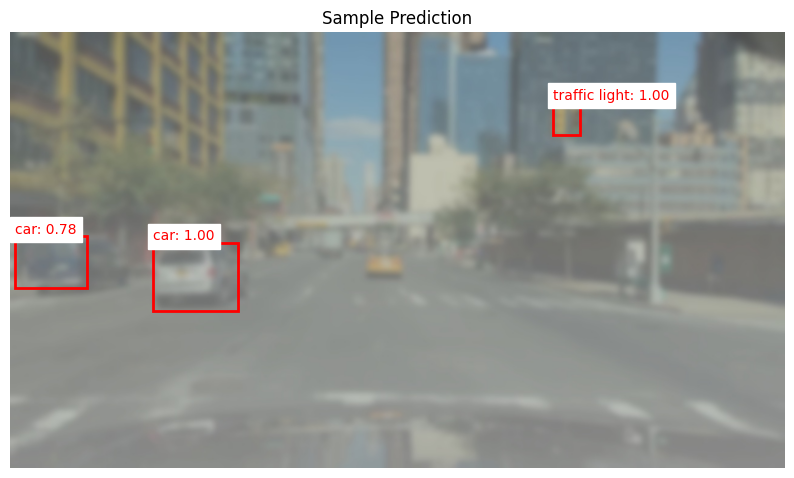

FOGGY Inference:   1%|          | 5/529 [00:01<03:05,  2.83it/s]

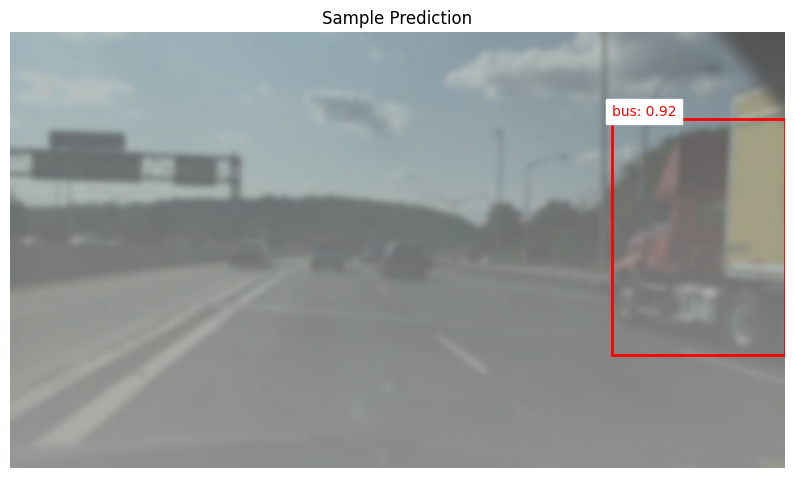

FOGGY Inference: 100%|██████████| 529/529 [01:24<00:00,  6.28it/s]



✅ Total valid predictions: 1324
⚠️ Skipped invalid predictions: 0
⚠️ Images with no predictions: 145
Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.69s).
Accumulating evaluation results...
DONE (t=0.15s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.012
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.022
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.011
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.002
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.012
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.050
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.011
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.017
 Average Recall     (AR) @[ IoU=0.50:0.95 | ar

In [ ]:
import os
import json
import torch
from tqdm import tqdm
from PIL import Image
from transformers import DetrForObjectDetection, DetrImageProcessor
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
import matplotlib.pyplot as plt


# === CONFIG ===
WEATHER_FOLDERS = ["foggy"]
VAL_ROOT = "/content/dataset/dataset/val"
MODEL_NAME = "facebook/detr-resnet-50"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === LOAD MODEL ===
processor = DetrImageProcessor.from_pretrained(MODEL_NAME)
model = DetrForObjectDetection.from_pretrained(MODEL_NAME).to(DEVICE)
model.eval()

def visualize_predictions(image_path, predictions, labels, scores):
    image = Image.open(image_path).convert("RGB")
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    ax.imshow(image)

    for box, label_id, score in zip(predictions, labels, scores):
        x0, y0, x1, y1 = box
        width, height = x1 - x0, y1 - y0
        label_name = model.config.id2label[label_id]
        ax.add_patch(plt.Rectangle((x0, y0), width, height, fill=False, color='red', linewidth=2))
        ax.text(x0, y0 - 5, f'{label_name}: {score:.2f}', color='red', fontsize=10, backgroundcolor='white')

    plt.axis('off')
    plt.title("Sample Prediction")
    plt.show()

# === INFERENCE + EVALUATION PER WEATHER ===
def run_evaluation(weather):
    img_dir = os.path.join(VAL_ROOT, weather, "images")
    ann_file = os.path.join(VAL_ROOT, weather, "coco_annotations.json")
    coco_gt = COCO(ann_file)
    remap = build_label_remap(ann_file)


    gt_cat_ids = coco_gt.getCatIds()
    # print(f"GT category IDs: {gt_cat_ids}")

    cats = coco_gt.loadCats(coco_gt.getCatIds())
    # print(sorted([(cat['id'], cat['name']) for cat in cats]))


    results = []
    skipped = 0
    empty_preds = 0
    visualized = 0



    for img_id in tqdm(coco_gt.getImgIds(), desc=f"{weather.upper()} Inference"):
        img_info = coco_gt.loadImgs(img_id)[0]
        img_path = os.path.join(img_dir, img_info['file_name'])

        image = Image.open(img_path).convert("RGB")
        inputs = processor(images=image, return_tensors="pt").to(DEVICE)

        with torch.no_grad():
            outputs = model(**inputs)

        target_sizes = torch.tensor([image.size[::-1]])  # (H, W)
        results_per_image = processor.post_process_object_detection(outputs, target_sizes=target_sizes, threshold=0.5)[0]

        if len(results_per_image["boxes"]) == 0:
            empty_preds += 1
            # print(f"⚠️ No predictions for image_id {img_id}")
            continue
        boxes_to_draw = []
        labels_to_draw = []
        scores_to_draw = []

        for box, score, label in zip(results_per_image["boxes"], results_per_image["scores"], results_per_image["labels"]):
            box = box.tolist()
            width = box[2] - box[0]
            height = box[3] - box[1]

            if width <= 0 or height <= 0:
                print(f"❌ Invalid box (zero or negative size) for image_id {img_id}: {box}")
                skipped += 1
                continue

            mapped_id = remap.get(label.item())
            if mapped_id is None:
                # print(f"⚠️ Skipping unmapped label {label.item()} for image {img_id}")
                continue

            # "category_id": mapped_id

            if mapped_id not in gt_cat_ids:
                # print(f"❌ Unknown category_id {mapped_id} for image_id {img_id}")
                skipped += 1
                continue

            results.append({
                "image_id": img_id,
                "category_id": mapped_id,
                "bbox": [box[0], box[1], width, height],  # [x, y, w, h]
                "score": score.item()
            })

            boxes_to_draw.append(box)
            labels_to_draw.append(label.item())
            scores_to_draw.append(score.item())

        # Visualize a few
        if visualized < 5 and boxes_to_draw:
            visualize_predictions(img_path, boxes_to_draw, labels_to_draw, scores_to_draw)
            visualized += 1

    print(f"\n✅ Total valid predictions: {len(results)}")
    print(f"⚠️ Skipped invalid predictions: {skipped}")
    print(f"⚠️ Images with no predictions: {empty_preds}")

    # Save & Evaluate
    output_file = f"detr_predictions_{weather.replace(' ', '_')}.json"
    with open(output_file, 'w') as f:
        json.dump(results, f)

    coco_dt = coco_gt.loadRes(output_file)
    coco_eval = COCOeval(coco_gt, coco_dt, iouType='bbox')
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()

# === RUN FOR EACH WEATHER CATEGORY ===
for weather in WEATHER_FOLDERS:
    weather_path = os.path.join(VAL_ROOT, weather)
    if os.path.exists(weather_path):
        run_evaluation(weather)
    else:
        print(f"Skipping {weather} (folder not found)")


In [ ]:
import os
import json
import torch
from tqdm import tqdm
from PIL import Image
from transformers import DetrForObjectDetection, DetrImageProcessor
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

# === CONFIG ===
WEATHER_FOLDERS = ["clear"]
VAL_ROOT = "/content/dataset/dataset/val"
MODEL_NAME = "facebook/detr-resnet-50"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === LOAD MODEL ===
processor = DetrImageProcessor.from_pretrained(MODEL_NAME)
model = DetrForObjectDetection.from_pretrained(MODEL_NAME).to(DEVICE)
model.eval()

# === INFERENCE + EVALUATION PER WEATHER ===
def run_evaluation(weather):
    img_dir = os.path.join(VAL_ROOT, weather, "images")
    ann_file = os.path.join(VAL_ROOT, weather, "coco_annotations.json")
    coco_gt = COCO(ann_file)

    results = []
    for img_id in tqdm(coco_gt.getImgIds(), desc=f"{weather.upper()} Inference"):
        # print("GT category IDs:", coco_gt.getCatIds())

        img_info = coco_gt.loadImgs(img_id)[0]
        img_path = os.path.join(img_dir, img_info['file_name'])

        image = Image.open(img_path).convert("RGB")
        inputs = processor(images=image, return_tensors="pt").to(DEVICE)

        with torch.no_grad():
            outputs = model(**inputs)

        target_sizes = torch.tensor([image.size[::-1]])  # (H, W)
        results_per_image = processor.post_process_object_detection(outputs, target_sizes=target_sizes, threshold=0.5)[0]

        for box, score, label in zip(results_per_image["boxes"], results_per_image["scores"], results_per_image["labels"]):
            box = box.tolist()
            results.append({
                "image_id": img_id,
                "category_id": label.item(),
                "bbox": [box[0], box[1], box[2]-box[0], box[3]-box[1]],  # to [x, y, w, h]
                "score": score.item()
            })

    # Save & Evaluate
    output_file = f"detr_predictions_{weather.replace(' ', '_')}.json"
    with open(output_file, 'w') as f:
        json.dump(results, f)

    coco_dt = coco_gt.loadRes(output_file)
    coco_eval = COCOeval(coco_gt, coco_dt, iouType='bbox')
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()

# === RUN FOR EACH WEATHER CATEGORY ===
for weather in WEATHER_FOLDERS:
    weather_path = os.path.join(VAL_ROOT, weather)
    if os.path.exists(weather_path):
        run_evaluation(weather)
    else:
        print(f"Skipping {weather} (folder not found)")


Some weights of the model checkpoint at facebook/detr-resnet-50 were not used when initializing DetrForObjectDetection: ['model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing DetrForObjectDetection from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DetrForObjectDetection from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


loading annotations into memory...
Done (t=0.02s)
creating index...
index created!


CLEAR Inference: 100%|██████████| 493/493 [01:12<00:00,  6.82it/s]


Loading and preparing results...
DONE (t=0.46s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=1.03s).
Accumulating evaluation results...
DONE (t=0.26s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.001
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.001
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

RAINY Inference: 100%|██████████| 543/543 [01:21<00:00,  6.64it/s]


Loading and preparing results...
DONE (t=0.04s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.74s).
Accumulating evaluation results...
DONE (t=0.22s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.017
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.029
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.020
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.006
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.037
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.026
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.027
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.027
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.027
 Average Recall     (AR) @[ IoU=0.50:0.95 | area= small | maxDets=10

In [ ]:
import torchvision.transforms.functional as F
import torchvision.transforms as T
import torch
import random
import math
import numpy as np
from PIL import Image

class DetectionTransforms:
    def __init__(self, min_size=800, max_size=1333, divisor=32, train=True):
        self.min_size = min_size
        self.max_size = max_size
        self.divisor = divisor
        self.train = train

        self.normalize = T.Normalize(mean=[0.485, 0.456, 0.406],
                                     std=[0.229, 0.224, 0.225])

    def resize_with_boxes(self, image, target):
        w, h = image.size
        scale = self.min_size / min(h, w)
        if max(h, w) * scale > self.max_size:
            scale = self.max_size / max(h, w)

        new_w, new_h = int(w * scale), int(h * scale)
        image = F.resize(image, (new_h, new_w))

        # Scale boxes
        boxes = target['boxes']
        boxes = boxes * torch.tensor([scale, scale, scale, scale])
        target['boxes'] = boxes

        target['scale'] = scale
        return image, target

    def pad_to_divisible(self, image, target):
        w, h = image.size
        pad_w = (self.divisor - w % self.divisor) % self.divisor
        pad_h = (self.divisor - h % self.divisor) % self.divisor
        image = F.pad(image, (0, 0, pad_w, pad_h), fill=0)
        return image, target

    def __call__(self, image, target):
        image, target = self.resize_with_boxes(image, target)

        if self.train and random.random() < 0.5:
            image = F.hflip(image)
            w = image.size[0]
            boxes = target['boxes']
            boxes[:, [0, 2]] = w - boxes[:, [2, 0]]  # flip x1 <-> x2
            target['boxes'] = boxes

        image, target = self.pad_to_divisible(image, target)

        image = F.to_tensor(image)
        image = self.normalize(image)

        return image, target


In [ ]:
from torch.utils.data import Dataset
from pycocotools.coco import COCO
from PIL import Image
import torch
import os

class CocoDetectionDataset(Dataset):
    def __init__(self, img_folder, ann_file, transforms=None):
        self.coco = COCO(ann_file)
        self.img_folder = img_folder
        self.transforms = transforms
        self.ids = list(self.coco.imgs.keys())

    def __getitem__(self, index):
        img_id = self.ids[index]
        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)
        img_meta = self.coco.loadImgs(img_id)[0]

        img_path = os.path.join(self.img_folder, img_meta["file_name"])
        img = Image.open(img_path).convert("RGB")

        boxes = []
        labels = []
        for ann in anns:
            if "bbox" in ann and ann["bbox"]:
                x, y, w, h = ann["bbox"]
                boxes.append([x, y, x + w, y + h])
                labels.append(ann["category_id"])

        target = {
            "boxes": torch.tensor(boxes, dtype=torch.float32),
            "labels": torch.tensor(labels, dtype=torch.int64),
            "image_id": torch.tensor([img_id])
        }

        if self.transforms:
            img, target = self.transforms(img, target)

        return img, target

    def __len__(self):
        return len(self.ids)


In [ ]:
train_transforms = DetectionTransforms(train=True)
val_transforms = DetectionTransforms(train=False)

In [ ]:
from torch.utils.data import DataLoader

# Paths
train_img_dir = "train/images/"
train_ann_file = "train/train_annotations.json"

val_img_dir = "val_split_by_weather/clear/images/"
val_ann_file = "val_split_by_weather/clear/coco_annotations.json"  # or any weather

# Datasets
train_dataset = CocoDetectionDataset(train_img_dir, train_ann_file, transforms=train_transforms)
val_dataset = CocoDetectionDataset(val_img_dir, val_ann_file, transforms=val_transforms)

# DataLoaders
def collate_fn(batch):
    return tuple(zip(*batch))

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, collate_fn=collate_fn, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False, collate_fn=collate_fn, num_workers=4)


In [ ]:
from torch.utils.data import Dataset
from pycocotools.coco import COCO
from PIL import Image
from transformers import DetrImageProcessor
import torch
import os

class HuggingFaceDetrDataset(Dataset):
    def __init__(self, image_dir, annotation_file, processor_name="facebook/detr-resnet-50"):
        self.image_dir = image_dir
        self.coco = COCO(annotation_file)
        self.image_ids = list(self.coco.imgs.keys())
        self.processor = DetrImageProcessor.from_pretrained(processor_name)

    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        img_info = self.coco.loadImgs(img_id)[0]
        img_path = os.path.join(self.image_dir, img_info['file_name'])
        image = Image.open(img_path).convert("RGB")

        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)

        # Prepare annotations in [x, y, w, h] format
        annotations = []
        for ann in anns:
            if 'bbox' in ann and ann['iscrowd'] == 0:
                annotations.append({
                    "bbox": ann["bbox"],
                    "category_id": ann["category_id"]
                })

        target = {
            "image_id": img_id,
            "annotations": annotations
        }

        encoding = self.processor(images=image, annotations=target, return_tensors="pt")
        # Squeeze removes batch dim from image and target dict
        pixel_values = encoding["pixel_values"].squeeze()
        labels = {k: v.squeeze() for k, v in encoding["labels"].items()}

        return pixel_values, labels

    def __len__(self):
        return len(self.image_ids)


In [ ]:
import os
import torch
from PIL import Image
from pycocotools.coco import COCO
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import numpy as np


# === Custom COCO Dataset with Albumentations ===
class CocoDetectionWithAlbumentations(Dataset):
    def __init__(self, image_dir, annotation_file, transforms=None, category_ids=None):
        self.image_dir = image_dir
        self.coco = COCO(annotation_file)
        self.ids = list(sorted(self.coco.imgs.keys()))
        self.transforms = transforms
        self.category_ids = category_ids

    def __getitem__(self, index):
        img_id = self.ids[index]
        ann_ids = self.coco.getAnnIds(imgIds=img_id)
        anns = self.coco.loadAnns(ann_ids)

        # Filter out invalid boxes and categories not in remap (if specified)
        if self.category_ids is not None:
            anns = [ann for ann in anns if ann['category_id'] in self.category_ids and ann['iscrowd'] == 0]

        img_info = self.coco.loadImgs(img_id)[0]
        img_path = os.path.join(self.image_dir, img_info['file_name'])
        image = Image.open(img_path).convert("RGB")
        image = np.array(image)

        boxes = []
        labels = []
        for ann in anns:
            x, y, w, h = ann['bbox']
            if w > 1 and h > 1:
                boxes.append([x, y, x + w, y + h])  # Convert to Pascal VOC format
                labels.append(ann['category_id'])

        if self.transforms:
            transformed = self.transforms(image=image, bboxes=boxes, class_labels=labels)
            image = transformed['image']
            boxes = transformed['bboxes']
            labels = transformed['class_labels']

        # Prepare target dictionary
        target = {}
        target['boxes'] = torch.tensor(boxes, dtype=torch.float32)
        target['labels'] = torch.tensor(labels, dtype=torch.int64)
        target['image_id'] = torch.tensor([img_id])

        return image, target

    def __len__(self):
        return len(self.ids)


# === Albumentations Transform Pipeline ===
def get_train_transforms():
    return A.Compose([
        A.LongestMaxSize(max_size=800),
        A.PadIfNeeded(min_height=800, min_width=800, border_mode=0),
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.2),
        A.Blur(p=0.1),
        A.Normalize(mean=(0.485, 0.456, 0.406),
                    std=(0.229, 0.224, 0.225)),
        ToTensorV2()
    ], bbox_params=A.BboxParams(format='pascal_voc', label_fields=['class_labels']))


# === Custom collate_fn for DataLoader ===
def collate_fn(batch):
    images, targets = list(zip(*batch))
    return list(images), list(targets)


# === Usage Example ===
if __name__ == '__main__':
    image_dir = "/content/dataset/train/images"
    annotation_file = "/content/dataset/train/coco_annotations.json"

    dataset = CocoDetectionWithAlbumentations(
        image_dir=image_dir,
        annotation_file=annotation_file,
        transforms=get_train_transforms(),
        category_ids=[1, 2, 3, 4, 5, 6, 7, 8, 9]
    )

    dataloader = DataLoader(
        dataset,
        batch_size=4,
        shuffle=True,
        num_workers=4,
        collate_fn=collate_fn
    )

    # Test a batch
    # for imgs, targets in dataloader:
    #     print("Batch of images:", len(imgs))
    #     print("First target sample:", targets[0])
    #     break


loading annotations into memory...
Done (t=5.09s)
creating index...
index created!


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Batch of images: 4
First target sample: {'boxes': tensor([[160.6250, 373.7500, 180.6250, 380.6250],
        [331.8750, 391.2500, 343.1250, 402.5000],
        [245.6250, 403.1250, 298.7500, 419.3750],
        [551.2500, 353.1250, 581.2500, 363.1250],
        [543.1250, 371.2500, 582.5000, 384.3750]]), 'labels': tensor([2, 2, 4, 2, 2]), 'image_id': tensor([15592])}


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.ops as ops

class DETRLikeModel(nn.Module):
    def __init__(self, num_classes=91, num_queries=100, hidden_dim=256):
        super().__init__()

        # === Backbone: ResNet-50 ===
        backbone = models.resnet50(pretrained=True)
        self.backbone = nn.Sequential(*list(backbone.children())[:-2])  # Remove avgpool & fc
        self.input_proj = nn.Conv2d(2048, hidden_dim, kernel_size=1)   # project to transformer dim

        # === Positional Encoding ===
        self.pos_embed = nn.Parameter(torch.rand(50, 50, hidden_dim))  # assume max 50x50 feature map

        # === Transformer ===
        self.transformer = nn.Transformer(
            d_model=hidden_dim,
            nhead=8,
            num_encoder_layers=6,
            num_decoder_layers=6
        )

        # === Learnable object queries ===
        self.query_embed = nn.Embedding(num_queries, hidden_dim)

        # === Prediction heads ===
        self.class_embed = nn.Linear(hidden_dim, num_classes + 1)  # +1 for no-object
        self.bbox_embed = MLP(hidden_dim, hidden_dim, 4, 3)        # [cx, cy, w, h] normalized

    def forward(self, images):
        # === Backbone ===
        features = self.backbone(images)                # (B, 2048, H, W)
        src = self.input_proj(features)                 # (B, 256, H, W)
        B, C, H, W = src.shape

        # === Positional encoding ===
        pos = self.pos_embed[:H, :W].permute(2, 0, 1).unsqueeze(0).repeat(B, 1, 1, 1)
        src = src + pos                                 # add positional encoding

        src = src.flatten(2).permute(2, 0, 1)           # (HW, B, C)
        queries = self.query_embed.weight.unsqueeze(1).repeat(1, B, 1)  # (num_queries, B, C)

        # === Transformer ===
        hs = self.transformer(src, queries)             # (num_queries, B, C)
        hs = hs.transpose(0, 1)                         # (B, num_queries, C)

        # === Predict ===
        outputs_class = self.class_embed(hs)            # (B, num_queries, num_classes+1)
        outputs_coord = self.bbox_embed(hs).sigmoid()   # normalized boxes

        return {"pred_logits": outputs_class, "pred_boxes": outputs_coord}


class MLP(nn.Module):
    """Simple 3-layer perceptron"""
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers):
        super().__init__()
        layers = []
        for i in range(num_layers):
            in_dim = input_dim if i == 0 else hidden_dim
            out_dim = output_dim if i == num_layers - 1 else hidden_dim
            layers.append(nn.Linear(in_dim, out_dim))
            if i < num_layers - 1:
                layers.append(nn.ReLU())
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


In [ ]:
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.optim import AdamW
from torchvision.ops import generalized_box_iou
from scipy.optimize import linear_sum_assignment

# === Hungarian Matcher ===
def match_predictions(outputs, targets):
    bs, num_queries = outputs['pred_logits'].shape[:2]

    out_prob = outputs['pred_logits'].softmax(-1)  # (bs, num_queries, num_classes)
    out_bbox = outputs['pred_boxes']               # (bs, num_queries, 4)

    indices = []
    for b in range(bs):
        tgt_ids = targets[b]['labels']
        tgt_bbox = targets[b]['boxes']

        cost_class = -out_prob[b][:, tgt_ids]       # (num_queries, num_target)
        cost_bbox = torch.cdist(out_bbox[b], tgt_bbox, p=1)
        cost_giou = -generalized_box_iou(ops.box_convert(out_bbox[b], 'cxcywh', 'xyxy'), tgt_bbox)

        C = cost_bbox + cost_class + cost_giou
        C = C.cpu()

        indices.append(linear_sum_assignment(C))

    return [(torch.as_tensor(i, dtype=torch.int64), torch.as_tensor(j, dtype=torch.int64)) for i, j in indices]

# === Loss Function ===
def detr_loss(outputs, targets, indices, num_classes):
    loss_ce = 0
    loss_bbox = 0
    loss_giou = 0
    num_boxes = sum(len(t['labels']) for t in targets)

    for i, (idx_pred, idx_tgt) in enumerate(indices):
        src_logits = outputs['pred_logits'][i][idx_pred]
        tgt_classes = targets[i]['labels'][idx_tgt]
        loss_ce += F.cross_entropy(src_logits, tgt_classes)

        src_boxes = outputs['pred_boxes'][i][idx_pred]
        tgt_boxes = targets[i]['boxes'][idx_tgt]

        loss_bbox += F.l1_loss(src_boxes, tgt_boxes, reduction='none').sum()
        loss_giou += (1 - torch.diag(generalized_box_iou(ops.box_convert(src_boxes, 'cxcywh', 'xyxy'), tgt_boxes))).sum()

    loss_ce /= num_boxes
    loss_bbox /= num_boxes
    loss_giou /= num_boxes

    return loss_ce + loss_bbox + loss_giou, {'ce': loss_ce.item(), 'bbox': loss_bbox.item(), 'giou': loss_giou.item()}

# === Training Loop ===
def train_one_epoch(model, dataloader, optimizer, device, num_classes):
    model.train()
    total_loss = 0

    for images, targets in dataloader:
        images = torch.stack(images).to(device)
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        outputs = model(images)
        indices = match_predictions(outputs, targets)

        loss, loss_dict = detr_loss(outputs, targets, indices, num_classes)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)



image_dir = "/path/to/train/images"
annotation_file = "/path/to/train/train_annotations.json"
num_classes = 9

dataset = CocoDetectionWithAlbumentations(
    image_dir=image_dir,
    annotation_file=annotation_file,
    transforms=get_train_transforms(),
    category_ids=list(range(1, 10))
)

dataloader = DataLoader(dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)
model = DETRLikeModel(num_classes=num_classes, num_queries=100, hidden_dim=256).to("cuda")

optimizer = AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

for epoch in range(10):
    loss = train_one_epoch(model, dataloader, optimizer, "cuda", num_classes)
    print(f"Epoch {epoch+1} Loss: {loss:.4f}")
